# Predictive Modeling Using Machine Learning
Using the Breast Cancer dataset to predict whether a tumor is malignant or benign.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_curve, auc
)

import warnings
warnings.filterwarnings('ignore')

## 1. Load and Explore the Dataset

In [2]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print("Shape:", df.shape)
print("\nTarget distribution:")
print(df['target'].value_counts().rename({0: 'Malignant', 1: 'Benign'}))
df.head()

Shape: (569, 31)

Target distribution:
target
Benign       357
Malignant    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
df.describe().T[['mean', 'std', 'min', 'max']].head(10)

,mean,std,min,max
mean radius,14.127292,3.524049,6.98100,28.11000
mean texture,19.289649,4.301036,9.71000,39.28000
mean perimeter,91.969033,24.298981,43.79000,188.50000
mean area,654.889104,351.914129,143.50000,2501.00000
mean smoothness,0.096360,0.014064,0.05263,0.16340
mean compactness,0.104341,0.052813,0.01938,0.34540
mean concavity,0.088799,0.079720,0.00000,0.42680
mean concave points,0.048919,0.038803,0.00000,0.20120
mean symmetry,0.181162,0.027414,0.10600,0.30400
mean fractal dimension,0.062798,0.007060,0.04996,0.09744


## 2. Visualize the Data

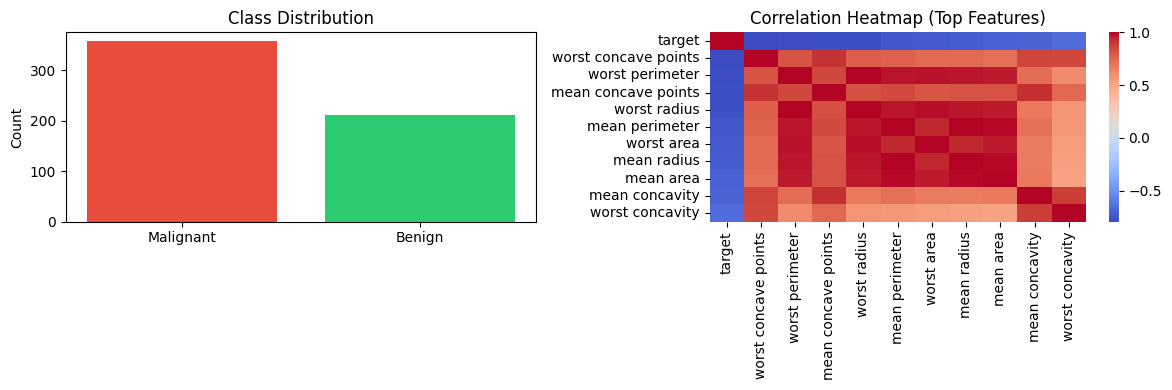

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution
axes[0].bar(['Malignant', 'Benign'], df['target'].value_counts().values, color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')

# Correlation heatmap (top 10 features)
top_features = df.corr()['target'].abs().nlargest(11).index
sns.heatmap(df[top_features].corr(), annot=False, cmap='coolwarm', ax=axes[1])
axes[1].set_title('Correlation Heatmap (Top Features)')

plt.tight_layout()
plt.savefig('eda.png', dpi=100, bbox_inches='tight')
plt.show()

## 3. Preprocess the Data

In [5]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

Train size: 455 | Test size: 114


## 4. Train Models

In [6]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {'model': model, 'y_pred': y_pred, 'accuracy': acc}
    print(f"{name}: Accuracy = {acc:.4f}")

Logistic Regression: Accuracy = 0.9825
Decision Tree: Accuracy = 0.9211


Random Forest: Accuracy = 0.9561


## 5. Classification Reports

In [7]:
for name, res in results.items():
    print(f"\n{'='*40}")
    print(f"  {name}")
    print('='*40)
    print(classification_report(y_test, res['y_pred'], target_names=['Malignant', 'Benign']))


  Logistic Regression
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


  Decision Tree
              precision    recall  f1-score   support

   Malignant       0.87      0.93      0.90        42
      Benign       0.96      0.92      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114


  Random Forest
              precision    recall  f1-score   support

   Malignant       0.95      0.93      0.94        42
      Benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg     

## 6. Confusion Matrices

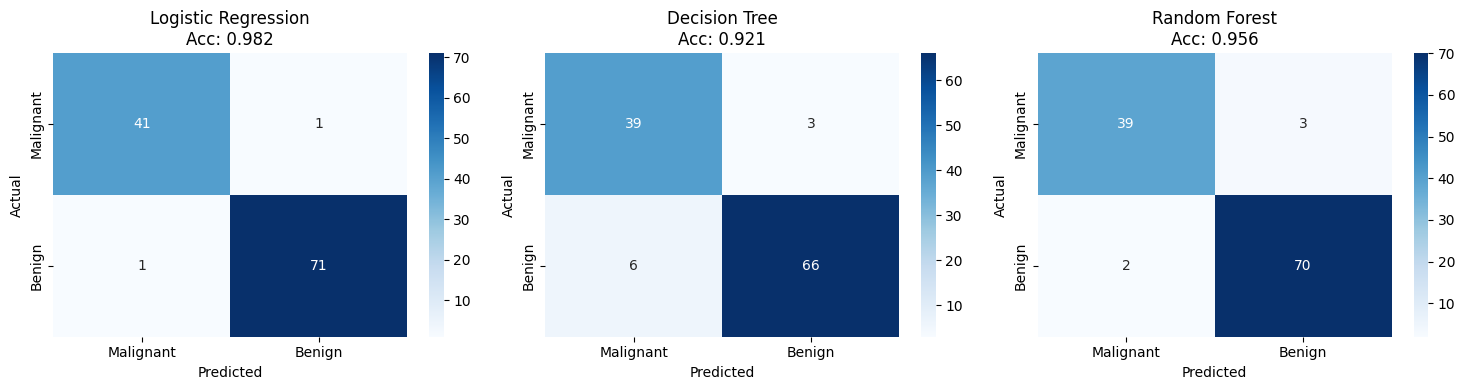

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Malignant', 'Benign'],
                yticklabels=['Malignant', 'Benign'])
    ax.set_title(f"{name}\nAcc: {res['accuracy']:.3f}")
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()

## 7. ROC Curves

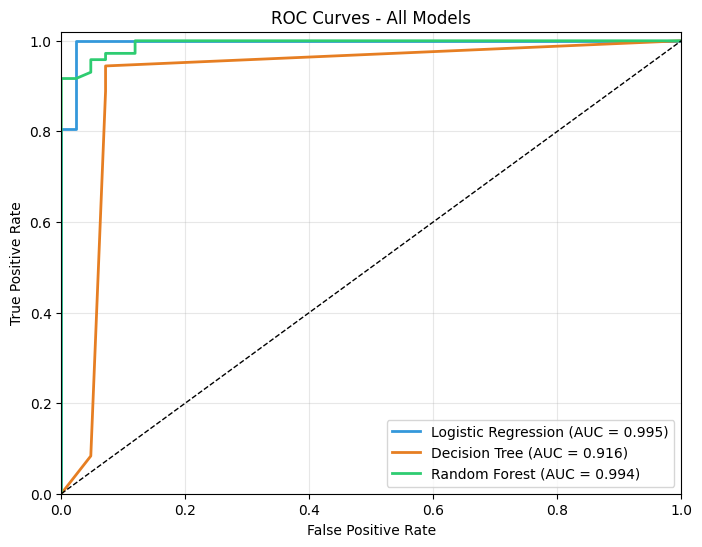

In [9]:
plt.figure(figsize=(8, 6))
colors = ['#3498db', '#e67e22', '#2ecc71']

for (name, res), color in zip(results.items(), colors):
    y_prob = res['model'].predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0, 1])
plt.ylim([0, 1.02])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.savefig('roc_curves.png', dpi=100, bbox_inches='tight')
plt.show()

## 8. Feature Importance (Random Forest)

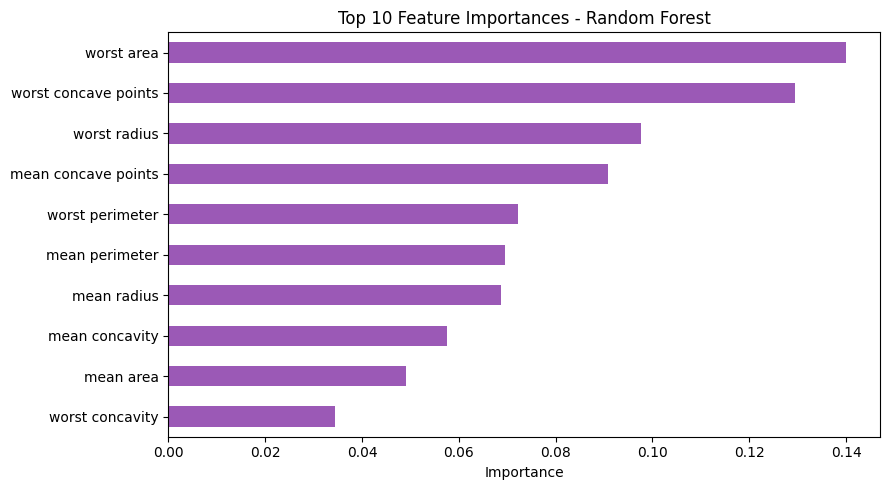

In [10]:
rf_model = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_, index=X.columns).nlargest(10)

plt.figure(figsize=(9, 5))
importances.sort_values().plot(kind='barh', color='#9b59b6')
plt.title('Top 10 Feature Importances - Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

## 9. Model Comparison Summary

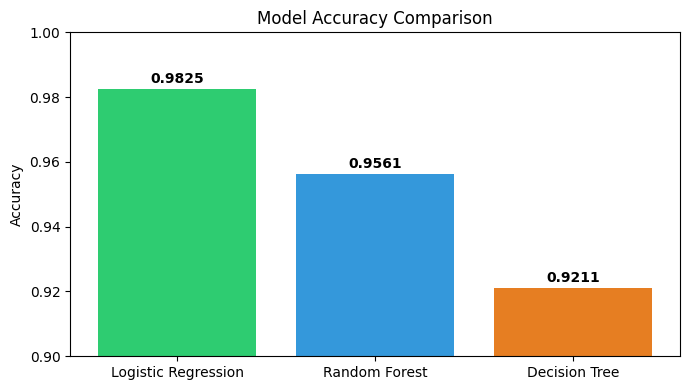

                 Model  Accuracy
0  Logistic Regression  0.982456
1        Random Forest  0.956140
2        Decision Tree  0.921053


In [11]:
summary = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [res['accuracy'] for res in results.values()]
}).sort_values('Accuracy', ascending=False).reset_index(drop=True)

plt.figure(figsize=(7, 4))
bars = plt.bar(summary['Model'], summary['Accuracy'], color=['#2ecc71', '#3498db', '#e67e22'])
plt.ylim([0.9, 1.0])
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
for bar, acc in zip(bars, summary['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print(summary)

## Conclusion

- All three models performed well on the Breast Cancer dataset.
- **Random Forest** achieved the highest accuracy due to its ensemble nature.
- **Logistic Regression** is simple but competitive and highly interpretable.
- **Decision Tree** is easy to visualize but can overfit without depth control.
- ROC-AUC scores confirm all models have strong discriminative power.
- Feature importance shows that `worst radius`, `worst perimeter`, and `worst concave points` are the most predictive features.